## Summary

The goal of this guide is to explore some of the main `scikit-learn` tools on a single practical task: analyzing a collection of text documents (newsgroups posts) on twenty different topics.

In this section we will see how to:
 - load the file contents and the categories
 - extract feature vectors suitable for machine learning
 - train a linear model to perform categorization
 - use a grid search strategy to find a good configuration of both the feature extraction components and the classifier

The dataset is called “Twenty Newsgroups”. Here is the official description, quoted from the [website](http://qwone.com/~jason/20Newsgroups/):

The 20 Newsgroups data set is a collection of approximately 20,000 newsgroup documents, partitioned (nearly) evenly across 20 different newsgroups.

In the following we will use the built-in dataset loader for 20 newsgroups from scikit-learn. Alternatively, it is possible to download the dataset manually from the website and use the sklearn.datasets.load_files function by pointing it to the 20news-bydate-train sub-folder of the uncompressed archive folder.

In order to get faster execution times for this first example we will work on a partial dataset with only 4 categories out of the 20 available in the dataset:

## Import libraries

In [1]:
import re
import warnings
from collections import Counter
from pathlib import Path

from loguru import logger
import matplotlib.pyplot as plt
import pandas as pd
import pyLDAvis
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn import set_config
from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             roc_auc_score,
                             confusion_matrix,
                            )
from sklearn.model_selection import GridSearchCV, cross_validate, StratifiedKFold
from wordcloud import WordCloud

set_config(display="diagram", print_changed_only=False)
# filter warnings
warnings.filterwarnings('ignore')

## Settings

In [2]:
ROOT_DIR = Path.cwd().parent  # project folder
DATA_DIR = Path(ROOT_DIR, "data")  # data
MODEL_DIR  = Path(ROOT_DIR, "models") # models

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

logger.info(f"\nRoot directory: {ROOT_DIR} \nData directory: {DATA_DIR} \nModel directory: {MODEL_DIR}")

2025-03-15 07:58:17.699 | INFO     | __main__:<module>:8 - 
Root directory: /Users/mouslydiaw/Documents/ml-courses/nlp 
Data directory: /Users/mouslydiaw/Documents/ml-courses/nlp/data 
Model directory: /Users/mouslydiaw/Documents/ml-courses/nlp/models


## Load data

In [3]:
categories = ['alt.atheism',
              'soc.religion.christian',
              'comp.graphics',
              'sci.med'
             ]

# We can now load the list of files matching those categories as follows:
# fetch_20newsgroups est une fonction de Scikit-learn qui permet de télécharger le dataset 20 Newsgroups, 
# une collection de documents texte issus de 20 forums de discussion couvrant divers sujets (politique, sport, informatique, etc.).
# Ce dataset est souvent utilisé pour des tâches de NLP, notamment la classification de texte.
twenty_train = fetch_20newsgroups(subset='train',
                                  categories=categories, 
                                  shuffle=True,
                                  random_state=42,
                                 )

twenty_test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)
docs_test = twenty_test.data

In [4]:
print(twenty_train.DESCR)

.. _20newsgroups_dataset:

The 20 newsgroups text dataset
------------------------------

The 20 newsgroups dataset comprises around 18000 newsgroups posts on
20 topics split in two subsets: one for training (or development)
and the other one for testing (or for performance evaluation). The split
between the train and test set is based upon a messages posted before
and after a specific date.

This module contains two loaders. The first one,
:func:`sklearn.datasets.fetch_20newsgroups`,
returns a list of the raw texts that can be fed to text feature
extractors such as :class:`~sklearn.feature_extraction.text.CountVectorizer`
with custom parameters so as to extract feature vectors.
The second one, :func:`sklearn.datasets.fetch_20newsgroups_vectorized`,
returns ready-to-use features, i.e., it is not necessary to use a feature
extractor.

**Data Set Characteristics:**

=================   ==========
Classes                     20
Samples total            18846
Dimensionality               1

In [5]:
LABELS = twenty_train.target_names
LABELS

['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']

In [6]:
data = pd.DataFrame({"text": twenty_train.data,
                     "target": twenty_train.target
                    })

print(f"Shape of data: {data.shape}")

Shape of data: (2257, 2)


In [7]:
data.head()

,text,target
0,From: sd345@city.ac.uk (Michael Collier)\nSubj...,1
1,From: ani@ms.uky.edu (Aniruddha B. Deglurkar)\...,1
2,From: djohnson@cs.ucsd.edu (Darin Johnson)\nSu...,3
3,From: s0612596@let.rug.nl (M.M. Zwart)\nSubjec...,3
4,From: stanly@grok11.columbiasc.ncr.com (stanly...,3


In [8]:
# It is possible to get back the category names as follows

data["target_name"] = data.target.map(lambda val: LABELS[val])
data.head()

,text,target,target_name
0,From: sd345@city.ac.uk (Michael Collier)\nSubj...,1,comp.graphics
1,From: ani@ms.uky.edu (Aniruddha B. Deglurkar)\...,1,comp.graphics
2,From: djohnson@cs.ucsd.edu (Darin Johnson)\nSu...,3,soc.religion.christian
3,From: s0612596@let.rug.nl (M.M. Zwart)\nSubjec...,3,soc.religion.christian
4,From: stanly@grok11.columbiasc.ncr.com (stanly...,3,soc.religion.christian


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2257 entries, 0 to 2256
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         2257 non-null   object
 1   target       2257 non-null   int64 
 2   target_name  2257 non-null   object
dtypes: int64(1), object(2)
memory usage: 53.0+ KB


In [9]:
data.describe(include="all")

,text,target,target_name
count,2257,2257.000000,2257
unique,2257,NaN,4
top,From: sd345@city.ac.uk (Michael Collier)\nSubj...,NaN,soc.religion.christian
freq,1,NaN,599
mean,NaN,1.581303,NaN
std,NaN,1.095472,NaN
min,NaN,0.000000,NaN
25%,NaN,1.000000,NaN
50%,NaN,2.000000,NaN
75%,NaN,3.000000,NaN


In [10]:
# Let’s print the first lines of the first loaded file:
print(data.loc[0, "text"])

From: sd345@city.ac.uk (Michael Collier)
Subject: Converting images to HP LaserJet III?
Nntp-Posting-Host: hampton
Organization: The City University
Lines: 14

Does anyone know of a good way (standard PC application/PD utility) to
convert tif/img/tga files into LaserJet III format.  We would also like to
do the same, converting to HPGL (HP plotter) files.

Please email any response.

Is this the correct group?

Thanks in advance.  Michael.
-- 
Michael Collier (Programmer)                 The Computer Unit,
Email: M.P.Collier@uk.ac.city                The City University,
Tel: 071 477-8000 x3769                      London,
Fax: 071 477-8565                            EC1V 0HB.



## Data exploration/viz

### Target analysis

In [81]:
label_distribution = data[["target", "target_name"]].value_counts(normalize=True)
label_distribution

target  target_name           
3       soc.religion.christian    0.265397
2       sci.med                   0.263181
1       comp.graphics             0.258751
0       alt.atheism               0.212672
Name: proportion, dtype: float64

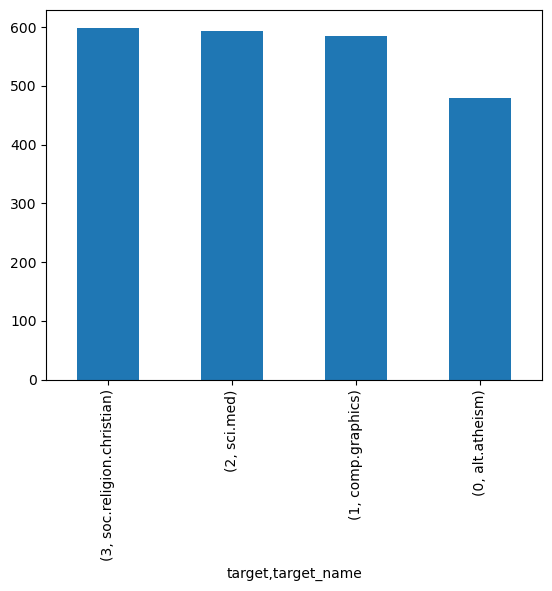

In [12]:
label_distribution.plot(kind="bar", );

### Word frequency

In [13]:
# Create a word_cloud from words and frequencies.

# get all verbatim
all_text = " ".join(data.text.str.lower())
words_frequency = Counter(all_text.split())

In [14]:
words_frequency.most_common(n=30)

[('the', 28956),
 ('of', 17381),
 ('to', 16419),
 ('a', 12808),
 ('and', 12356),
 ('is', 11716),
 ('in', 10577),
 ('that', 9922),
 ('i', 8670),
 ('it', 6239),
 ('for', 5712),
 ('you', 5199),
 ('>', 5077),
 ('not', 4804),
 ('be', 4758),
 ('are', 4565),
 ('this', 4406),
 ('have', 4113),
 ('as', 3833),
 ('with', 3518),
 ('on', 3514),
 ('but', 3204),
 ('or', 3081),
 ('if', 2976),
 ('was', 2727),
 ('by', 2448),
 ('we', 2426),
 ('can', 2363),
 ('from', 2356),
 ('from:', 2342)]

import nltk
nltk.download('stopwords')

In [19]:
set(stopwords.fileids())

{'albanian',
 'arabic',
 'azerbaijani',
 'basque',
 'belarusian',
 'bengali',
 'catalan',
 'chinese',
 'danish',
 'dutch',
 'english',
 'finnish',
 'french',
 'german',
 'greek',
 'hebrew',
 'hinglish',
 'hungarian',
 'indonesian',
 'italian',
 'kazakh',
 'nepali',
 'norwegian',
 'portuguese',
 'romanian',
 'russian',
 'slovene',
 'spanish',
 'swedish',
 'tajik',
 'turkish'}

In [27]:
# get list of stopwords
stopwords_nltk = set(stopwords.words('english'))

def display_wordcloud(corpus, title=""):
    plt.figure(figsize=(10, 5))
    wc = WordCloud(background_color="white",
                   max_words=1000,
                   colormap='hsv',
                   stopwords=None, # stopwords_nltk,
                   collocations=False)
    # generate word cloud
    # wc.generate_from_frequencies(words_frequency)
    wc.generate_from_text(corpus)
    plt.imshow(wc, interpolation="bilinear")
    plt.title(title)
    plt.axis("off");

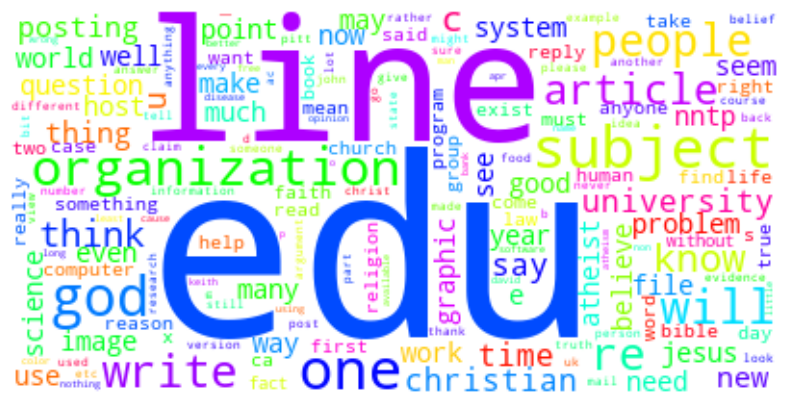

In [28]:
display_wordcloud(corpus=all_text)

""


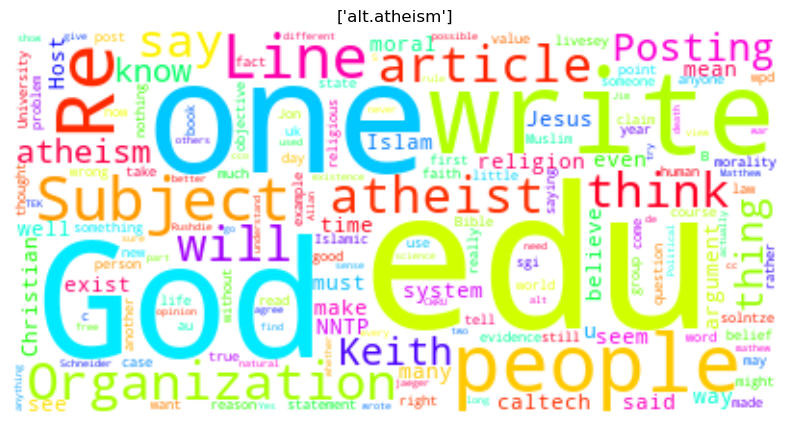

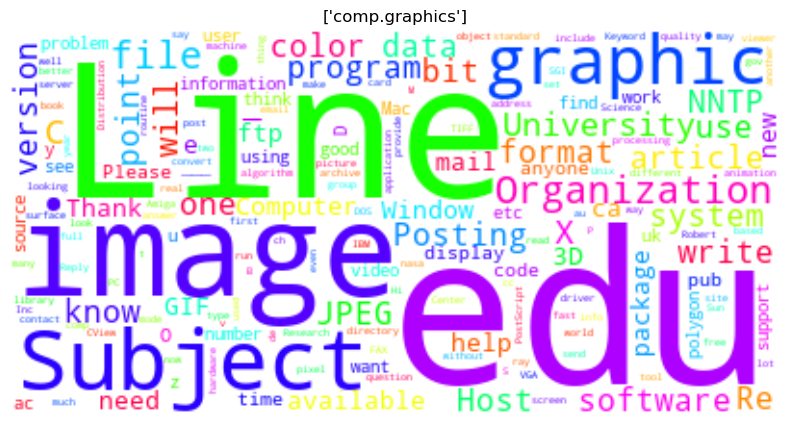

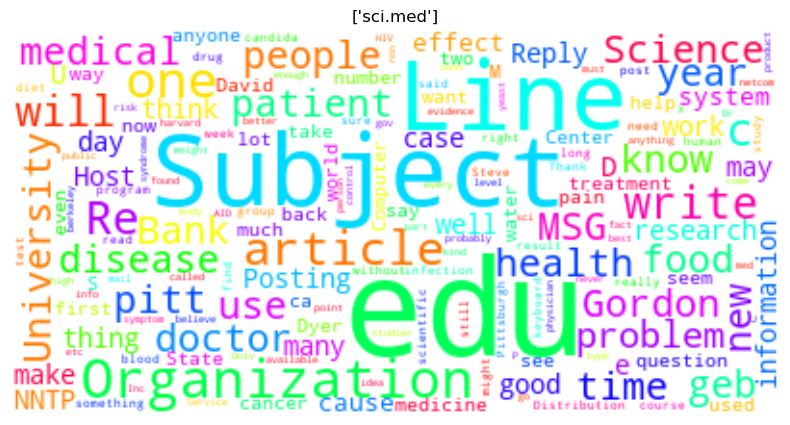

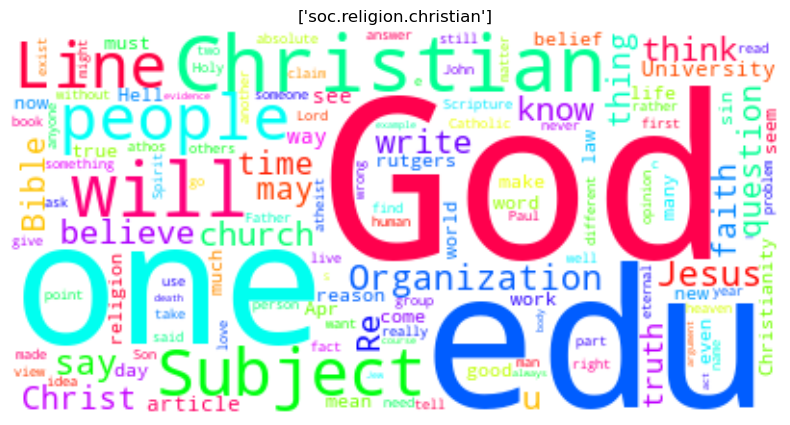

In [29]:
# wordcloud by target
data.groupby("target_name").apply(
    lambda group: display_wordcloud(" ".join(group.text), title=group.target_name.unique()))

## Modeling

**1- Preprocessing**

    a. Data Cleaning
    b. Vectorizer: Tf-idf; word embeddings, ...

**2- Models**

We will benchmark the 6 models below (supervised learning: classification) in order to choice the best:
    
    1. Logistic regression
    2. Multinomial Naive Bayes
    3. Perceptron
    4. Random Forest
   
We use:

- **Pipeline** : apply intermediate steps a list of transforms and a final estimator.

- **Cross validation** : evaluate estimator performance to avoid overfitting or underfitting
   
- __GridSearch__ : tun the best parameters for each model 

**4- Performance metrics**
\begin{equation*}
real_{value}  
\begin{vmatrix}
&\mathbf{predict} &\\
 & + &  -  \\
\hline \\
+ & T_p & F_n  \\
- & F_p & T_n
\end{vmatrix}
\end{equation*} 

- **[Accuracy](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)** : $   \frac{T_P + T_n}{N} $  avec $ N =   T_p + F_n  + F_p + T_n $
    
- **[Précision](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score)**: $ P =  \frac{T_P}{T_p + F_p} $
    
- **[Recall](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html#sklearn.metrics.recall_score)**: $ R =  \frac{T_P}{T_p + F_n} $
- **[f1-score](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score)** : $ f_1 =  2 \frac{P \times R}{P + R} $

**Meta metrics**

- **`Micro average`**
    -  precision: $\frac{\sum_{i=1}^KT_P^i}{\sum_{i=1}^K (T_p^i + F_p^i)}$
    
    -  recall: $\frac{\sum_{i=1}^KT_P^i}{\sum_{i=1}^K (T_p^i + F_n^i)}$


- **`Macro average`**
    -  precision $\frac{\sum_{i=1}^KP^i}{K}$
    
    -  recall: $\frac{\sum_{i=1}^KR^i}{K}$


- **`Weighted average`**
    -  precision: $\frac{\sum_{i=1}^K n_iP^i}{N}$
    
    -  recall: $\frac{\sum_{i=1}^K n_iR^i}{N}$

The best model is the one with the highest values !

### Text preprocessing

#### Define preprocessing function

In [12]:
def preprocess_text(text, language="english", stopwords=None, normalizer="stem"):
    
    valid_normalizer = (None, "stem", "lemma")
    if not normalizer in valid_normalizer:
        raise ValueError(f"`normalizer` must be in `{valid_normalizer}`")
    # lower case
    text = text.lower()
    
    # delete html balise
    # We can also use BeautifulSoup package to get the text from HTML document
    # re: regular expression
    text = re.sub(re.compile('<.*?>'), '', text)
    
    # remove url
    text = re.sub(r'(http|www)\S*', '', text)

    # delete email
    text = re.sub(r"\S*@\S*\s*", "", text)
    
    # delete special character
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # delete number
    text = re.sub(r'[0-9]+', '', text).strip()
    
    # tokenizer 
    text_tokens = word_tokenize(text)
    
    # remove stopword
    if isinstance(stopwords, (set, list, tuple)):
        # split sentence
        text_tokens = [word for word in text_tokens if word not in stopwords]
    # stem string: snowball stemmer
    if normalizer == "stem":
        stemmer = SnowballStemmer(language, ignore_stopwords=True)
        text_tokens = [stemmer.stem(wrd) for wrd in text_tokens]
    elif normalizer == "lemma":
        lemmatizer = WordNetLemmatizer()
        text_tokens = [lemmatizer.lemmatize(wrd) for wrd in text_tokens]
         
    return " ".join(text_tokens)

In [52]:
# test preprocessing
sentence = data.text.iloc[0]
sentence

'From: sd345@city.ac.uk (Michael Collier)\nSubject: Converting images to HP LaserJet III?\nNntp-Posting-Host: hampton\nOrganization: The City University\nLines: 14\n\nDoes anyone know of a good way (standard PC application/PD utility) to\nconvert tif/img/tga files into LaserJet III format.  We would also like to\ndo the same, converting to HPGL (HP plotter) files.\n\nPlease email any response.\n\nIs this the correct group?\n\nThanks in advance.  Michael.\n-- \nMichael Collier (Programmer)                 The Computer Unit,\nEmail: M.P.Collier@uk.ac.city                The City University,\nTel: 071 477-8000 x3769                      London,\nFax: 071 477-8565                            EC1V 0HB.\n'

In [53]:
# without delete stop word et normalizer
preprocess_text(sentence, stopwords=None, normalizer=None)

'from michael collier subject converting images to hp laserjet iii nntp posting host hampton organization the city university lines does anyone know of a good way standard pc application pd utility to convert tif img tga files into laserjet iii format we would also like to do the same converting to hpgl hp plotter files please email any response is this the correct group thanks in advance michael michael collier programmer the computer unit email the city university tel x london fax ecv hb'

In [56]:
# delete stop words in text
preprocess_text(sentence, stopwords=stopwords_nltk, normalizer=None)

'michael collier subject converting images hp laserjet iii nntp posting host hampton organization city university lines anyone know good way standard pc application pd utility convert tif img tga files laserjet iii format would also like converting hpgl hp plotter files please email response correct group thanks advance michael michael collier programmer computer unit email city university tel x london fax ecv hb'

In [57]:
# normalizer with stemmer
preprocess_text(sentence, stopwords=stopwords_nltk, normalizer="stem")

'michael collier subject convert imag hp laserjet iii nntp post host hampton organ citi univers line anyon know good way standard pc applic pd util convert tif img tga file laserjet iii format would also like convert hpgl hp plotter file pleas email respons correct group thank advanc michael michael collier programm comput unit email citi univers tel x london fax ecv hb'

In [60]:
# normalize without lemmatizer
preprocess_text(sentence, stopwords=stopwords_nltk, normalizer="lemma")

'michael collier subject converting image hp laserjet iii nntp posting host hampton organization city university line anyone know good way standard pc application pd utility convert tif img tga file laserjet iii format would also like converting hpgl hp plotter file please email response correct group thanks advance michael michael collier programmer computer unit email city university tel x london fax ecv hb'

In [59]:
# Add new words in the list of stopwords
custom_stopwords = ["subject", "email"]

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/mouslydiaw/nltk_data...


True

#### Add new column for sanitizing

In [63]:
%%time
# add new columns for sanitizing
data = data.assign(text_sanitize=lambda dfr: dfr.text.apply(preprocess_text, stopwords=stopwords_nltk, normalizer=None),
                   text_sanitize_stem=lambda dfr: dfr.text.apply(preprocess_text, stopwords=stopwords_nltk, normalizer="stem"),
                   text_sanitize_lemma=lambda dfr: dfr.text.apply(preprocess_text, stopwords=stopwords_nltk, normalizer="lemma")
                  )

CPU times: user 5.53 s, sys: 88.2 ms, total: 5.61 s
Wall time: 5.66 s


In [64]:
data.head()

,text,target,target_name,text_sanitize,text_sanitize_stem,text_sanitize_lemma
0,From: sd345@city.ac.uk (Michael Collier)\nSubj...,1,comp.graphics,michael collier subject converting images hp l...,michael collier subject convert imag hp laserj...,michael collier subject converting image hp la...
1,From: ani@ms.uky.edu (Aniruddha B. Deglurkar)\...,1,comp.graphics,aniruddha b deglurkar subject help splitting t...,aniruddha b deglurkar subject help split trim ...,aniruddha b deglurkar subject help splitting t...
2,From: djohnson@cs.ucsd.edu (Darin Johnson)\nSu...,3,soc.religion.christian,darin johnson subject harrassed work could use...,darin johnson subject harrass work could use p...,darin johnson subject harrassed work could use...
3,From: s0612596@let.rug.nl (M.M. Zwart)\nSubjec...,3,soc.religion.christian,zwart subject catholic church poland organizat...,zwart subject cathol church poland organ facul...,zwart subject catholic church poland organizat...
4,From: stanly@grok11.columbiasc.ncr.com (stanly...,3,soc.religion.christian,stanly subject elder brother organization ncr ...,stan subject elder brother organ ncr corp colu...,stanly subject elder brother organization ncr ...


### Extracting features from text files

In order to perform machine learning on text documents, we first need to turn the text content into numerical feature vectors.



**Bags of words**

The most intuitive way to do so is to use a bags of words representation:

 - Assign a fixed integer id to each word occurring in any document of the training set (for instance by building a dictionary from words to integer indices).

 - For each document `#i`, count the number of occurrences of each word w and store it in `X[i, j]` as the value of feature `#j` where `j` is the index of word w in the dictionary.
 
Fortunately, **most values in X will be zeros** since for a given document less than a few thousand distinct words will be used. 

Different Methods to vectorize a corpus of documents:
 - NLTK
 - spaCy
 - Gensim
 - fastText

#### Count vectorizer
[CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html#sklearn.feature_extraction.text.CountVectorizer) supports counts of N-grams of words or consecutive characters. Once fitted, the vectorizer has built a dictionary of feature indices:

In [66]:
# get all documents (corpus)
corpus = data.text_sanitize
target = data.target

In [76]:
count_vect = CountVectorizer(max_df=1., min_df=1, binary=False)
X_train_counts = count_vect.fit_transform(corpus)
X_train_counts.shape

(2257, 29166)

In [77]:
(X_train_counts.toarray())

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [78]:
count_vect.vocabulary_.get('algorithm')

1102

#### From occurrences to frequencies

Occurrence count is a good start but there is an issue: longer documents will have higher average count values than shorter documents, even though they might talk about the same topics.

To avoid these potential discrepancies it suffices to divide the number of occurrences of each word in a document by the total number of words in the document: these new features are called tf for Term Frequencies.

Another refinement on top of tf is to downscale weights for words that occur in many documents in the corpus and are therefore less informative than those that occur only in a smaller portion of the corpus.

This downscaling is called tf–idf for “Term Frequency times Inverse Document Frequency”.


In [79]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(corpus)
X_train_tfidf.shape

(2257, 29166)

In [80]:
X_train_tfidf.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

### Classifier

#### Naive classifier

##### Training

In [82]:
clf = MultinomialNB().fit(X_train_tfidf, target)

##### Prediction

To try to predict the outcome on a new document we need to extract the features using almost the same feature extracting chain as before. The difference is that we call `transform` instead of `fit_transform` on the transformers, since they have already been fit to the training set:

In [84]:
docs_new = ['God is love', 'OpenGL on the GPU is fast']

X_new_counts = count_vect.transform(docs_new)
X_new_tfidf = tfidf_vectorizer.transform(docs_new)

predicted = clf.predict(X_new_tfidf)

for doc, category in zip(docs_new, predicted):
    print(f"{doc} => {LABELS[category]}")

God is love => soc.religion.christian
OpenGL on the GPU is fast => comp.graphics


#### Baseline pipeline


##### Training

In order to make the vectorizer => classifier easier to work with, `scikit-learn` provides a Pipeline class that behaves like a compound classifier:

In [91]:
mnb_clf_pipe = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', MultinomialNB()),  # LogisticRegression
])
mnb_clf_pipe

Pipeline(memory=None,
         steps=[('vectorizer',
                 TfidfVectorizer(analyzer='word', binary=False,
                                 decode_error='strict',
                                 dtype=<class 'numpy.float64'>,
                                 encoding='utf-8', input='content',
                                 lowercase=True, max_df=0.95, max_features=None,
                                 min_df=1, ngram_range=(1, 1), norm='l2',
                                 preprocessor=None, smooth_idf=True,
                                 stop_words=None, strip_accents=None,
                                 sublinear_tf=False,
                                 token_pattern='(?u)\\b\\w\\w+\\b',
                                 tokenizer=None, use_idf=True,
                                 vocabulary=None)),
                ('classifier',
                 MultinomialNB(alpha=1.0, class_prior=None, fit_prior=True,
                               force_alpha=True))],
         verbose=False)

The names vectorizer and classifier are arbitrary. We will use them to perform grid search for suitable hyperparameters below. We can now train the model with a single command:

In [86]:
mnb_clf_pipe.fit(corpus, target)

Pipeline(memory=None,
         steps=[('vectorizer',
                 TfidfVectorizer(analyzer='word', binary=False,
                                 decode_error='strict',
                                 dtype=<class 'numpy.float64'>,
                                 encoding='utf-8', input='content',
                                 lowercase=True, max_df=1.0, max_features=None,
                                 min_df=1, ngram_range=(1, 1), norm='l2',
                                 preprocessor=None, smooth_idf=True,
                                 stop_words=None, strip_accents=None,
                                 sublinear_tf=False,
                                 token_pattern='(?u)\\b\\w\\w+\\b',
                                 tokenizer=None, use_idf=True,
                                 vocabulary=None)),
                ('classifier',
                 MultinomialNB(alpha=1.0, class_prior=None, fit_prior=True,
                               force_alpha=True))],
         verbose=False)

##### Prediction

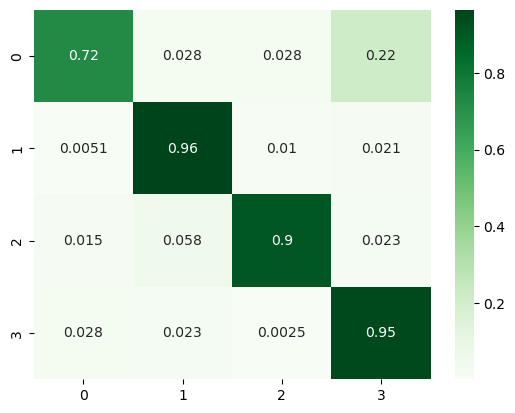

In [90]:
sns.heatmap(confusion_matrix(twenty_test.target, test_predicted, normalize="true"),
           annot=True, fmt='.2g', cmap="Greens");

In [92]:
print(classification_report(predicted, twenty_test.target, target_names=twenty_test.target_names))

                        precision    recall  f1-score   support

           alt.atheism       0.72      0.92      0.81       250
         comp.graphics       0.96      0.90      0.93       416
               sci.med       0.90      0.96      0.93       372
soc.religion.christian       0.95      0.81      0.87       464

              accuracy                           0.89      1502
             macro avg       0.88      0.90      0.89      1502
          weighted avg       0.90      0.89      0.89      1502



#### Fine-tuning

Optimiser les hyperparamètres, au moins 2 de chaque, du pipeline mnb_clf_pipe
- Tfidf
- MultinomialNB

In [98]:
# Define hyperparams
mnb_param_grid = {
    "vectorizer__max_df": [0.75, 0.85, 1.0],
    "vectorizer__min_df": [1, 5, .01, .05],
    "vectorizer__ngram_range": [(1, 1), (1, 2)],
    # "vectorizer__use_idf":  [True, False],

    "classifier__alpha": [.1, 1., 10],  # Laplace
    "classifier__fit_prior": [True, False],
    "classifier__force_alpha": [True, False],
}

In [101]:
# Search best params
# stratified cross validate
skf = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

mnb_grid_search = GridSearchCV(mnb_clf_pipe, mnb_param_grid, cv=skf,
                               scoring="f1_macro",  # accuracy, f1_macro, f1_weighted, precision_weighted, recall_weighted 
                               n_jobs=-1, verbose=1, return_train_score=True,
                              )
mnb_grid_search.fit(corpus, target)

# Display best params
print(f"Best params : {mnb_grid_search.best_params_}")
print(f"Best accuracy : {mnb_grid_search.best_score_}")

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best params : {'classifier__alpha': 0.1, 'classifier__fit_prior': False, 'classifier__force_alpha': True, 'vectorizer__max_df': 0.75, 'vectorizer__min_df': 1, 'vectorizer__ngram_range': (1, 2)}
Best accuracy : 0.9747422838198035


In [107]:
pd.DataFrame(mnb_grid_search.cv_results_).sort_values("mean_test_score", ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__alpha,param_classifier__fit_prior,param_classifier__force_alpha,param_vectorizer__max_df,param_vectorizer__min_df,param_vectorizer__ngram_range,...,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
67,0.655493,0.037988,0.193017,0.010652,0.1,False,False,1.00,1,"(1, 2)",...,0.978723,0.964096,0.974742,0.007608,1,0.999335,1.000000,0.999336,0.999557,0.000313
37,0.663844,0.039973,0.165046,0.019054,0.1,False,True,0.75,1,"(1, 2)",...,0.978723,0.964096,0.974742,0.007608,1,0.999335,1.000000,0.999336,0.999557,0.000313
61,0.793332,0.031815,0.165846,0.020983,0.1,False,False,0.85,1,"(1, 2)",...,0.978723,0.964096,0.974742,0.007608,1,0.999335,1.000000,0.999336,0.999557,0.000313
43,0.730605,0.020862,0.177959,0.028953,0.1,False,True,0.85,1,"(1, 2)",...,0.978723,0.964096,0.974742,0.007608,1,0.999335,1.000000,0.999336,0.999557,0.000313
55,0.672551,0.031433,0.171458,0.012752,0.1,False,False,0.75,1,"(1, 2)",...,0.978723,0.964096,0.974742,0.007608,1,0.999335,1.000000,0.999336,0.999557,0.000313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,0.614777,0.040318,0.145461,0.014955,10.0,True,False,0.75,1,"(1, 2)",...,0.859043,0.852394,0.853347,0.004314,211,0.906250,0.906312,0.895681,0.902748,0.004997
145,0.615981,0.074872,0.169561,0.042172,10.0,True,True,0.75,1,"(1, 2)",...,0.859043,0.852394,0.853347,0.004314,211,0.906250,0.906312,0.895681,0.902748,0.004997
169,0.815135,0.043304,0.139089,0.010508,10.0,True,False,0.85,1,"(1, 2)",...,0.859043,0.852394,0.853347,0.004314,211,0.906250,0.906312,0.895681,0.902748,0.004997
157,0.608451,0.022368,0.151549,0.020262,10.0,True,True,1.00,1,"(1, 2)",...,0.857713,0.847074,0.850246,0.005300,215,0.906250,0.906312,0.895681,0.902748,0.004997


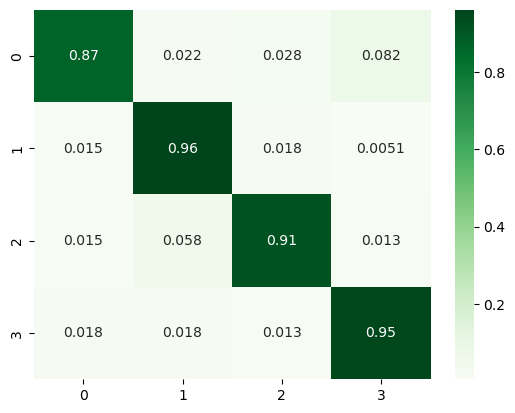

In [115]:
# Evaluer le modèle optimiser: mnb_grid_search

mnb_optimized_test_predict = mnb_grid_search.predict(docs_test)

sns.heatmap(confusion_matrix(twenty_test.target, mnb_optimized_test_predict, normalize="true"),
            annot=True, fmt='.2g', cmap="Greens");

In [116]:
print(classification_report(twenty_test.target, mnb_optimized_test_predict,
                            target_names=twenty_test.target_names))

                        precision    recall  f1-score   support

           alt.atheism       0.94      0.87      0.90       319
         comp.graphics       0.91      0.96      0.94       389
               sci.med       0.95      0.91      0.93       396
soc.religion.christian       0.92      0.95      0.94       398

              accuracy                           0.93      1502
             macro avg       0.93      0.92      0.93      1502
          weighted avg       0.93      0.93      0.93      1502



### Random forest

We achieved 82% accuracy. Let’s see if we can do better with a random forest classifier, which is widely regarded as one of the best text classification algorithms (although it’s also a bit slower than naïve Bayes). We can change the learner by simply plugging a different classifier object into our pipeline:

#### Baseline

In [117]:
rf_clf_pipe = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', RandomForestClassifier()),
])
rf_clf_pipe

Pipeline(memory=None,
         steps=[('vectorizer',
                 TfidfVectorizer(analyzer='word', binary=False,
                                 decode_error='strict',
                                 dtype=<class 'numpy.float64'>,
                                 encoding='utf-8', input='content',
                                 lowercase=True, max_df=1.0, max_features=None,
                                 min_df=1, ngram_range=(1, 1), norm='l2',
                                 preprocessor=None, smooth_idf=True,
                                 stop_words=None, strip_accents=None,
                                 sublinear_tf=False,
                                 token_patt...
                 RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                        class_weight=None, criterion='gini',
                                        max_depth=None, max_features='sqrt',
                                        max_leaf_nodes=None, max_samples=None,
                                        min_impurity_decrease=0.0,
                                        min_samples_leaf=1, min_samples_split=2,
                                        min_weight_fraction_leaf=0.0,
                                        monotonic_cst=None, n_estimators=100,
                                        n_jobs=None, oob_score=False,
                                        random_state=None, verbose=0,
                                        warm_start=False))],
         verbose=False)

In [118]:
rf_clf_pipe.fit(corpus, target)
rf_predicted = rf_clf_pipe.predict(docs_test)

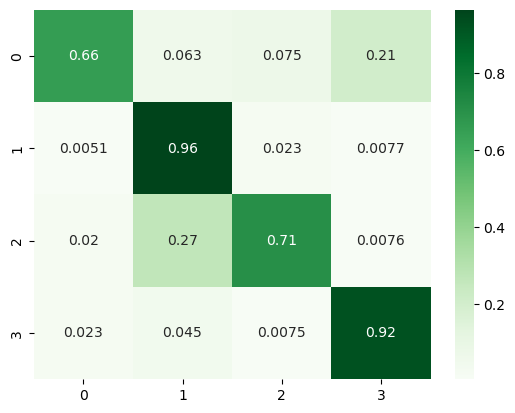

In [119]:
sns.heatmap(confusion_matrix(twenty_test.target, rf_predicted, normalize="true"),
            annot=True, fmt='.2g', cmap="Greens");

In [120]:
print(classification_report(twenty_test.target, rf_predicted,
                            target_names=twenty_test.target_names))

                        precision    recall  f1-score   support

           alt.atheism       0.92      0.66      0.76       319
         comp.graphics       0.72      0.96      0.83       389
               sci.med       0.89      0.71      0.79       396
soc.religion.christian       0.84      0.92      0.88       398

              accuracy                           0.82      1502
             macro avg       0.84      0.81      0.81      1502
          weighted avg       0.84      0.82      0.82      1502



#### Fine tuning

In [ ]:
# Optuna, hyperopt

In [123]:
rf_grid_params = {
    "vectorizer__max_df": (0.75, 0.9, 1.0),
    "vectorizer__min_df": (0.001, 0.01, 0.05),
    'vectorizer__use_idf': (True, False),
    'vectorizer__norm': ('l1', 'l2'),
    
    # classifier hyperparameters
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, 12],
    'classifier__min_samples_split': [2, 5, 10],
}

rf_grid_search = GridSearchCV(rf_clf_pipe, rf_grid_params, cv=skf, n_jobs=-1, verbose=1, scoring="f1_weighted")

rf_grid_search.fit(corpus, target)

# Display best params
print(f"Best params : {rf_grid_search.best_params_}")
print(f"Best accuracy : {rf_grid_search.best_score_}")

Fitting 3 folds for each of 972 candidates, totalling 2916 fits
Best params : {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200, 'vectorizer__max_df': 0.75, 'vectorizer__min_df': 0.001, 'vectorizer__norm': 'l2', 'vectorizer__use_idf': False}
Best accuracy : 0.9065616416699037


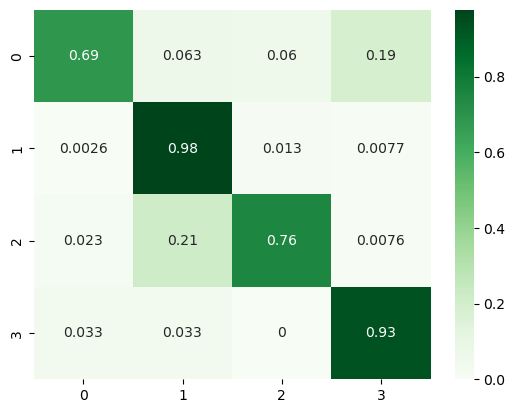

In [126]:
# Evaluer le modèle optimiser: mnb_grid_search

rf_optimized_test_predict = rf_grid_search.predict(docs_test)

sns.heatmap(confusion_matrix(twenty_test.target, rf_optimized_test_predict, normalize="true"),
            annot=True, fmt='.2g', cmap="Greens");

### Todo

- Tester et optimiser regression logistique et 2 autres modèles ensemblistes
- Choisir le meilleur modèle et justifier

### Word embeddings

#### Word2Vec

In [16]:
import numpy as np
from gensim.utils import simple_preprocess
from gensim.models import Word2Vec, FastText as gs_FastText

In [10]:
data.head()

,text,target
0,From: sd345@city.ac.uk (Michael Collier)\nSubj...,1
1,From: ani@ms.uky.edu (Aniruddha B. Deglurkar)\...,1
2,From: djohnson@cs.ucsd.edu (Darin Johnson)\nSu...,3
3,From: s0612596@let.rug.nl (M.M. Zwart)\nSubjec...,3
4,From: stanly@grok11.columbiasc.ncr.com (stanly...,3


##### Vectorization

In [13]:
# Preprocess
w2v_tokenized_train = [preprocess_text(doc, normalizer=None).split() for doc in data["text"]]  # simple_preprocess(doc)
w2v_tokenized_test = [preprocess_text(doc, normalizer=None).split() for doc in twenty_test.data]  # simple_preprocess(doc)

# Train Word2Vec
w2v_model = Word2Vec(
    sentences=w2v_tokenized_train,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1, # 1 for skip-gram; otherwise CBOW
)

# Save model
w2v_model.save(str(Path(MODEL_DIR, "word2vec_20news.model")))

In [14]:
def document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

# train / test split
X_train = np.array([document_vector(doc, w2v_model) for doc in w2v_tokenized_train])
y_train = data.target

X_test = np.array([document_vector(doc, w2v_model) for doc in w2v_tokenized_test])
y_test = twenty_test.target

# Ou X_train, X_test, y_train, y_test = train_test_split(w2v_tokenized_train, y_target, test_size=0.2, random_state=42)

In [15]:
list(w2v_model.wv.key_to_index) 

['the',
 'of',
 'to',
 'a',
 'and',
 'is',
 'i',
 'in',
 'that',
 'it',
 'you',
 'for',
 'not',
 'this',
 'be',
 'from',
 'are',
 's',
 'have',
 'as',
 'on',
 'with',
 't',
 'but',
 'or',
 'if',
 'can',
 'was',
 'we',
 'there',
 'by',
 'what',
 'subject',
 'they',
 'an',
 'lines',
 'one',
 'do',
 'he',
 'god',
 'organization',
 'at',
 're',
 'about',
 'my',
 'all',
 'would',
 'will',
 'so',
 'some',
 'your',
 'who',
 'no',
 'has',
 'any',
 'writes',
 'people',
 'which',
 'me',
 'article',
 'don',
 'his',
 'more',
 'other',
 'know',
 'when',
 'think',
 'their',
 'm',
 'like',
 'university',
 'does',
 'out',
 'just',
 'only',
 'how',
 'd',
 'also',
 'been',
 'than',
 'were',
 'then',
 'time',
 'because',
 'them',
 'posting',
 'up',
 'am',
 'had',
 'should',
 'these',
 'many',
 'say',
 'jesus',
 'may',
 'see',
 'why',
 'get',
 'very',
 'good',
 'believe',
 'use',
 'such',
 'even',
 'our',
 'us',
 'could',
 'well',
 'host',
 'x',
 'most',
 'those',
 'being',
 'nntp',
 'way',
 'new',
 'much

In [16]:
# List of vocabulary words
vocab = list(w2v_model.wv.index_to_key)  # Pour gensim >= 4.0, you can use 'index_to_key'

# Display examples
print(vocab[10:])

['you', 'for', 'not', 'this', 'be', 'from', 'are', 's', 'have', 'as', 'on', 'with', 't', 'but', 'or', 'if', 'can', 'was', 'we', 'there', 'by', 'what', 'subject', 'they', 'an', 'lines', 'one', 'do', 'he', 'god', 'organization', 'at', 're', 'about', 'my', 'all', 'would', 'will', 'so', 'some', 'your', 'who', 'no', 'has', 'any', 'writes', 'people', 'which', 'me', 'article', 'don', 'his', 'more', 'other', 'know', 'when', 'think', 'their', 'm', 'like', 'university', 'does', 'out', 'just', 'only', 'how', 'd', 'also', 'been', 'than', 'were', 'then', 'time', 'because', 'them', 'posting', 'up', 'am', 'had', 'should', 'these', 'many', 'say', 'jesus', 'may', 'see', 'why', 'get', 'very', 'good', 'believe', 'use', 'such', 'even', 'our', 'us', 'could', 'well', 'host', 'x', 'most', 'those', 'being', 'nntp', 'way', 'new', 'much', 'now', 'into', 'here', 'world', 'e', 'graphics', 'edu', 'question', 'something', 'him', 'must', 'where', 'things', 'image', 've', 'science', 'anyone', 'make', 'said', 'did', '

##### Word similarity / vector

In [58]:
# Word similarity
logger.info(f"Most similar words: {w2v_model.wv.most_similar('god', topn=5)}")

# Score similarity between two word
logger.info(f"Word similarity: {w2v_model.wv.similarity('computer', 'technology')}")

# Word vecttor
logger.info(f"Word vector: {w2v_model.wv['science']}")  # 100-dimension vector

2025-03-11 11:21:29.358 | INFO     | __main__:<module>:2 - Most similar words: [('himself', 0.7076995372772217), ('lord', 0.7064024806022644), ('salvation', 0.7032123804092407), ('father', 0.6950259804725647), ('spirit', 0.6825724840164185)]
2025-03-11 11:21:29.360 | INFO     | __main__:<module>:5 - Word similarity: 0.5872892141342163
2025-03-11 11:21:29.362 | INFO     | __main__:<module>:8 - Word vector: [-0.15804663  0.16475405  0.27390727 -0.11087637 -0.08335464 -0.37789518
  0.47410554 -0.41515124  0.09920815 -0.84485877 -0.13098489  0.11453886
 -0.81795496 -0.537206    0.7151485  -0.38423288 -0.28251943  0.20983355
 -0.2962827  -0.1380667   0.27822608  0.2117827   0.30950886 -0.37248087
 -0.42162684  0.24846613 -0.7785149   0.05560115 -0.34872466  0.2544968
  0.29878202  0.09502251  0.6588691  -0.78331745  0.00788162 -0.31871808
  0.42630097 -0.28148368 -0.3134586  -0.23124656  0.64984274 -0.08537826
 -0.29403704 -0.04322228  0.64231485  0.05947114 -0.21763676  0.02789089
  0.7584

##### Training

In [63]:
clf = LogisticRegression()  # LogisticRegression(max_iter=1000), RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=categories))

                        precision    recall  f1-score   support

           alt.atheism       0.79      0.59      0.67       319
soc.religion.christian       0.90      0.93      0.91       389
         comp.graphics       0.89      0.84      0.86       396
               sci.med       0.73      0.89      0.80       398

              accuracy                           0.82      1502
             macro avg       0.83      0.81      0.81      1502
          weighted avg       0.83      0.82      0.82      1502



##### Training with pipeline

In [26]:
from sklearn.base import BaseEstimator, TransformerMixin

class MeanEmbeddingVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, model):
        self.model = model
        self.vector_size = model.vector_size

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return np.array([document_vector(doc, self.model) for doc in X])

In [64]:
pipeline = Pipeline([
    ('w2v_vectorizer', MeanEmbeddingVectorizer(w2v_model)),
    ('clf', LogisticRegression())
])

pipeline.fit(w2v_tokenized_train, y_train)
print(classification_report(y_test, pipeline.predict(w2v_tokenized_test), target_names=categories))

                        precision    recall  f1-score   support

           alt.atheism       0.79      0.59      0.67       319
soc.religion.christian       0.90      0.93      0.91       389
         comp.graphics       0.89      0.84      0.86       396
               sci.med       0.73      0.89      0.80       398

              accuracy                           0.82      1502
             macro avg       0.83      0.81      0.81      1502
          weighted avg       0.83      0.82      0.82      1502



##### Visualisation

In [44]:
from sklearn.manifold import TSNE

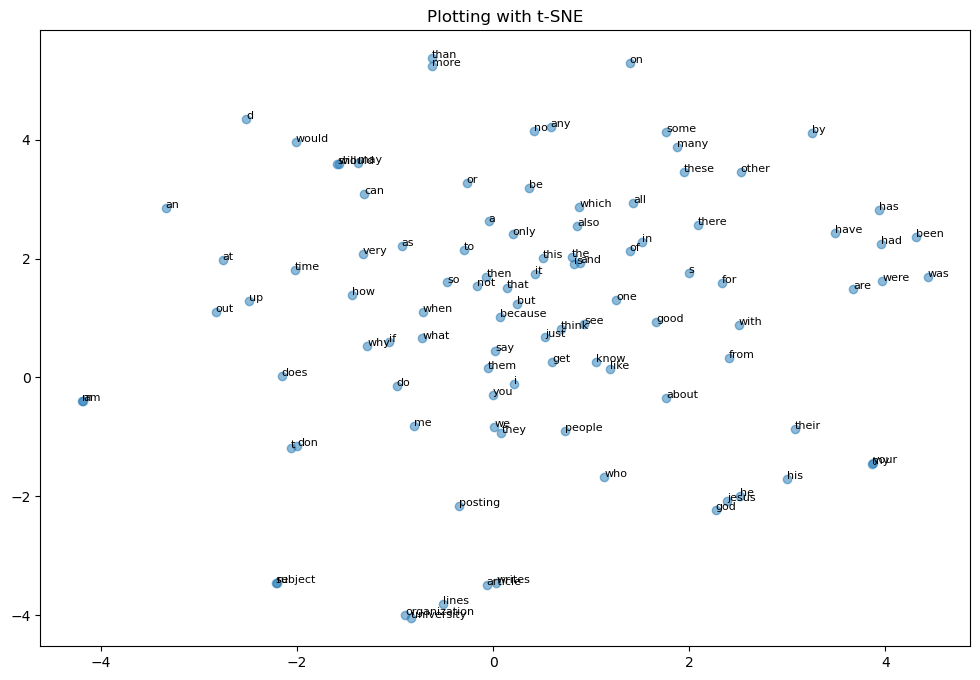

In [46]:
# Vocabulary
words = list(w2v_model.wv.index_to_key)

# Word vector
word_vectors = [w2v_model.wv[word] for word in words]

# Dimension reduction
nb_words = 100
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(np.asarray(word_vectors[:nb_words]))

# Plotting
plt.figure(figsize=(12, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5)

# Add words in the plot
for i, word in enumerate(words[:nb_words]):
    plt.annotate(word, (X_tsne[i, 0], X_tsne[i, 1]), fontsize=8)

plt.title("Plotting with t-SNE")
plt.show()

In [ ]:
# Todo:
- Revoir le preprocessing des documents (supprimer les mots avec un seul caractère, les mots très rares ou trop fréquent)
- Tester le CBOW, voire optimiser au moins trois hyperparamètres du modèle word2vec
- Comparer avec le meilleur modèle dans la partie 1 (Vectorisation basée sur la fréquence des mots)

#### FastText

In [20]:
# Train fastText model
ft_model = gs_FastText(
    w2v_tokenized_train,     # Documents tokenisés
    vector_size=100,    # Dimension des embeddings
    window=5,           # Taille de la fenêtre de contexte
    min_count=5,        # Ignorer les mots avec une fréquence < min_count
    sg=1,               # 1 pour Skip-Gram, 0 pour CBOW
    workers=4           # Nombre de threads pour l'entraînement
)

# Save model
ft_model.save(str(Path(MODEL_DIR, "fasttext_20newsgroups.model")))

In [27]:
ft_pipeline = Pipeline([
    ('w2v_vectorizer', MeanEmbeddingVectorizer(ft_model)),
    ('clf', LogisticRegression())
])

ft_pipeline.fit(w2v_tokenized_train, y_train)
print(classification_report(y_test, ft_pipeline.predict(w2v_tokenized_test), target_names=categories))

                        precision    recall  f1-score   support

           alt.atheism       0.80      0.58      0.68       319
soc.religion.christian       0.89      0.93      0.91       389
         comp.graphics       0.86      0.87      0.86       396
               sci.med       0.76      0.88      0.82       398

              accuracy                           0.83      1502
             macro avg       0.83      0.82      0.82      1502
          weighted avg       0.83      0.83      0.82      1502



In [ ]:
# To do:

- Entrainer le modèle de classification avec la librairrie fastText de facebook (https://fasttext.cc/)

#### GloVe

### Transformers

#### BERT

#### USE